[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Quantlets/Ch_12/SFM_ch12_seminar/SFM_ch12_seminar.ipynb)

# Statistics of Financial Markets — Seminar 12: Scoring models

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 12: the slides "What You Need for Today" give every definition used here.
- Part A: computations on paper, checked in code. Part B: real data with inference and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> Quantlet `SFM_ch12_seminar`: student version of the Seminar 12 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_12'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- **South German Credit** (Grömping, 2019; UCI Machine Learning Repository, doi:10.24432/C5QG88, CC BY 4.0): 1000 consumer credits of a regional bank in southern Germany, 1973–1975; 300 bad and 700 good credits (bad credits oversampled; the bank's bad rate was about 5%). It corrects the coding errors of the widely used UCI "Statlog (German Credit)" version.
- **Default of Credit Card Clients** (Yeh and Lien, 2009; UCI, doi:10.24432/C55S3H, CC BY 4.0): 30,000 card holders in Taiwan; default on the October 2005 payment (22.1%).
- Both files are saved in `data/credit` of the SFM repository and read locally or from GitHub in Colab. Default = 1 for a bad credit or a missed payment.

In [ ]:
CREDIT_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/credit/'
FILES = {'sgc': 'south_german_credit.csv', 'taiwan': 'taiwan_credit_card_default.csv'}
SEED = 2026
TEST_SHARE = 0.3
POP_BAD = 0.05
COST_FN = 5.0
COST_FP = 1.0
PDO, BASE_SCORE, BASE_ODDS = 20.0, 600.0, 50.0
IV_MIN = 0.1
N_REPEAT, N_FOLD = 20, 5
BINS = {'duration': [12, 18, 24, 36, np.inf], 'amount': [1300, 2000, 3000, 5000, np.inf], 'age': [25, 30, 35, 45, np.inf]}
NUMERIC = ['duration', 'amount', 'age']
SGC_VARS = ['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']
STATUS = {1: 'no checking account', 2: 'balance < 0 DM', 3: '0 to 200 DM', 4: '>= 200 DM or salary account'}
TW_FEATURES = ['log_limit', 'age', 'pay0_m2', 'pay0_m1', 'pay0_1', 'pay0_2', 'pay0_3', 'late_months', 'util', 'log_pay1', 'log_pay2', 'log_pay3']
COLORS = {'good': '#1A3A6E', 'bad': '#CD0000', 'logit': '#CD0000', 'lda': '#1A3A6E', 'single': '#B5853F', 'small': '#2E7D32', 'random': '#8E44AD', 'perfect': '#E67E22'}


def load_credit(name='sgc'):
    """A credit data set from data/credit (local copy) or from the raw GitHub URL; adds 'default' (1 = bad)."""
    fn = FILES[name]
    local = next((os.path.join(d, 'data', 'credit', fn) for d in ('.', '..', '../..', '../../..')
                  if os.path.exists(os.path.join(d, 'data', 'credit', fn))), None)
    df = pd.read_csv(local or CREDIT_RAW + fn)
    if name == 'sgc':
        df['default'] = 1 - df['credit_risk']
    return df


def taiwan_features(df):
    """Model inputs of the Taiwan data: log limit, age, the repayment status of September 2005 as indicators (-2 no
    consumption, -1 paid in full, 1, 2, 3+ months late; 0 = minimum paid is the reference), the number of late months
    April-August, utilisation (bill / limit, clipped to [-1, 3]) and log payments of the last three months."""
    X = pd.DataFrame(index=df.index)
    X['log_limit'] = np.log(df['LIMIT_BAL'])
    X['age'] = df['AGE']
    p0 = df['PAY_0']
    X['pay0_m2'] = (p0 == -2).astype(int)
    X['pay0_m1'] = (p0 == -1).astype(int)
    X['pay0_1'] = (p0 == 1).astype(int)
    X['pay0_2'] = (p0 == 2).astype(int)
    X['pay0_3'] = (p0 >= 3).astype(int)
    X['late_months'] = sum((df[c] >= 1).astype(int) for c in ['PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'])
    X['util'] = (df['BILL_AMT1'] / df['LIMIT_BAL']).clip(-1, 3)
    for i in (1, 2, 3):
        X[f'log_pay{i}'] = np.log1p(df[f'PAY_AMT{i}'].clip(lower=0))
    return X


def stratified_split(y, share=TEST_SHARE, seed=SEED):
    """Indices of a stratified train/test split (the same share of bads in both samples)."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    test = []
    for c in (0, 1):
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        test.append(idx[:int(round(share * len(idx)))])
    test = np.sort(np.concatenate(test))
    train = np.setdiff1d(np.arange(len(y)), test)
    return train, test

## Seminar functions

- WoE and IV, logit and LDA, AUC with DeLong standard errors, ROC, CAP, KS, Brier score, calibration, confusion matrix, scorecard scaling and prior correction, the Basel IRB capital, the Taiwan logit.
- Helpers for Part A: the PD of an applicant, WoE and IV from counts, the metrics of a small sample, scorecard scaling, attribute points, prior correction and expected loss.
- Constants: `A5`, `A6` (the small samples of Part A) and `SMALL` (the coefficients of the logit of A1).

In [ ]:
A5 = {'pd': [0.05, 0.1, 0.12, 0.2, 0.25, 0.3, 0.4, 0.55, 0.6, 0.8], 'y': [0, 0, 0, 0, 1, 0, 0, 1, 0, 1]}
A6 = {'pd': [0.08, 0.15, 0.22, 0.35, 0.42, 0.5, 0.65, 0.9], 'y': [0, 0, 1, 0, 0, 1, 1, 0]}
SMALL = {'const': -2.101, 'duration_years': 0.385, 'age_decades': -0.159, 'amount_1000': 0.029, 'no_account': 1.859, 'negative_balance': 1.338}


def bin_values(x, var):
    """Bin labels of a variable: fixed bins for duration, amount and age, the category code otherwise."""
    if var in BINS:
        edges = [-np.inf] + BINS[var]
        return pd.cut(x, edges, right=True, labels=False).astype(int)
    return x.astype(int)


def woe_table(x, y, var):
    """WoE_i = ln(share of goods in bin i / share of bads in bin i); IV = sum (g_i/G - b_i/B) WoE_i.
    Bins without goods or without bads get 0.5 added to both counts (no infinite WoE)."""
    b = bin_values(pd.Series(x).reset_index(drop=True), var)
    y = pd.Series(np.asarray(y))
    t = pd.DataFrame({'bin': b, 'y': y}).groupby('bin')['y'].agg(n='size', bad='sum')
    t['good'] = t['n'] - t['bad']
    adj = ((t['good'] == 0) | (t['bad'] == 0)) * 0.5
    g, bd = t['good'] + adj, t['bad'] + adj
    t['bad_rate'] = t['bad'] / t['n']
    t['dist_good'] = g / g.sum()
    t['dist_bad'] = bd / bd.sum()
    t['woe'] = np.log(t['dist_good'] / t['dist_bad'])
    t['iv'] = (t['dist_good'] - t['dist_bad']) * t['woe']
    return t


def iv_all(df, y, variables=SGC_VARS):
    """Information value of every variable, largest first."""
    return pd.Series({v: woe_table(df[v], y, v)['iv'].sum() for v in variables}).sort_values(ascending=False)


def iv_strength(iv):
    """Rule of thumb (Siddiqi, 2006): < 0.02 useless, 0.02-0.1 weak, 0.1-0.3 medium, >= 0.3 strong."""
    return 'useless' if iv < 0.02 else 'weak' if iv < 0.1 else 'medium' if iv < 0.3 else 'strong'


def woe_transform(df, tables, variables):
    """Replace every value by the WoE of its bin (tables estimated on the training sample)."""
    out = pd.DataFrame(index=df.index)
    for v in variables:
        b = bin_values(df[v], v)
        out[v] = b.map(tables[v]['woe']).fillna(0.0).values
    return out


def logit_fit(X, y):
    """Logistic regression by maximum likelihood (Newton-Raphson): ln(p/(1-p)) = b0 + x'b.
    Returns the coefficients (constant first), standard errors and the log-likelihood."""
    X = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
    y = np.asarray(y, float)
    b = np.zeros(X.shape[1])
    for _ in range(100):
        p = 1 / (1 + np.exp(-X @ b))
        W = p * (1 - p)
        H = X.T @ (X * W[:, None])
        step = np.linalg.solve(H, X.T @ (y - p))
        b += step
        if np.max(np.abs(step)) < 1e-10:
            break
    p = 1 / (1 + np.exp(-X @ b))
    H = X.T @ (X * (p * (1 - p))[:, None])
    se = np.sqrt(np.diag(np.linalg.inv(H)))
    ll = float(np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)))
    return {'b': b, 'se': se, 'll': ll, 'n': len(y)}


def logit_predict(fit, X):
    X = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
    return 1 / (1 + np.exp(-X @ fit['b']))


def lda_fit(X, y):
    """Fisher's linear discriminant: w = S_W^{-1}(m_1 - m_0) maximises the between/within variance ratio of w'x;
    with Normal classes and a common covariance, ln odds(bad | x) = c + w'x (the prior enters only c)."""
    X = np.asarray(X, float)
    y = np.asarray(y)
    m0, m1 = X[y == 0].mean(0), X[y == 1].mean(0)
    n0, n1 = (y == 0).sum(), (y == 1).sum()
    S = ((X[y == 0] - m0).T @ (X[y == 0] - m0) + (X[y == 1] - m1).T @ (X[y == 1] - m1)) / (n0 + n1 - 2)
    w = np.linalg.solve(S, m1 - m0)
    pi1 = n1 / (n0 + n1)
    c = -0.5 * (m1 + m0) @ w + np.log(pi1 / (1 - pi1))
    return {'w': w, 'c': float(c), 'm0': m0, 'm1': m1, 'S': S, 'pi1': float(pi1)}


def lda_predict(fit, X):
    """Posterior probability of default from the LDA log-odds."""
    return 1 / (1 + np.exp(-(fit['c'] + np.asarray(X, float) @ fit['w'])))


def auc(score, y):
    """AUC = P(score of a random bad > score of a random good) (ties count 1/2), via the Mann-Whitney ranks."""
    score, y = np.asarray(score, float), np.asarray(y)
    r = stats.rankdata(score)
    n1, n0 = (y == 1).sum(), (y == 0).sum()
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def delong(score, y, score2=None):
    """DeLong et al. (1988): standard error of the AUC; with a second score on the same cases, the test of
    equal AUCs (z statistic and two-sided p-value)."""
    def comps(s):
        s = np.asarray(s, float)
        pos, neg = s[np.asarray(y) == 1], s[np.asarray(y) == 0]
        v10 = np.array([np.mean((p > neg) + 0.5 * (p == neg)) for p in pos])
        v01 = np.array([np.mean((pos > q) + 0.5 * (pos == q)) for q in neg])
        return v10, v01
    a10, a01 = comps(score)
    A = a10.mean()
    if score2 is None:
        var = np.var(a10, ddof=1) / len(a10) + np.var(a01, ddof=1) / len(a01)
        return {'auc': float(A), 'se': float(np.sqrt(var)), 'lo': float(A - 1.96 * np.sqrt(var)),
                'hi': float(A + 1.96 * np.sqrt(var))}
    b10, b01 = comps(score2)
    S10 = np.cov(np.vstack([a10, b10]))
    S01 = np.cov(np.vstack([a01, b01]))
    var = (S10[0, 0] + S10[1, 1] - 2 * S10[0, 1]) / len(a10) + (S01[0, 0] + S01[1, 1] - 2 * S01[0, 1]) / len(a01)
    z = (A - b10.mean()) / np.sqrt(var)
    return {'auc1': float(A), 'auc2': float(b10.mean()), 'z': float(z), 'p': float(2 * stats.norm.sf(abs(z)))}


def roc_points(score, y):
    """ROC curve: (FPR, TPR) when every score value is used as the cut-off (a higher score = riskier)."""
    score, y = np.asarray(score, float), np.asarray(y)
    thr = np.r_[np.inf, np.unique(score)[::-1]]
    tpr = np.array([np.mean(score[y == 1] >= t) for t in thr])
    fpr = np.array([np.mean(score[y == 0] >= t) for t in thr])
    return fpr, tpr, thr


def cap_points(score, y):
    """CAP (cumulative accuracy profile): share of all bads among the riskiest x% of the applicants."""
    score, y = np.asarray(score, float), np.asarray(y)
    order = np.argsort(-score, kind='mergesort')
    x = np.r_[0, np.arange(1, len(y) + 1) / len(y)]
    hit = np.r_[0, np.cumsum(y[order]) / y.sum()]
    return x, hit


def accuracy_ratio(score, y):
    """AR = (area between the model CAP and the diagonal) / (area between the perfect CAP and the diagonal);
    for a continuous score AR = Gini = 2 AUC - 1."""
    x, hit = cap_points(score, y)
    a_model = np.trapezoid(hit, x) - 0.5
    pbad = np.mean(y)
    a_perf = (1 - pbad / 2) - 0.5
    return float(a_model / a_perf)


def ks_stat(score, y):
    """Kolmogorov-Smirnov: the largest distance between the score distributions of the bads and the goods."""
    score, y = np.asarray(score, float), np.asarray(y)
    s = np.sort(np.unique(score))
    F1 = np.searchsorted(np.sort(score[y == 1]), s, side='right') / (y == 1).sum()
    F0 = np.searchsorted(np.sort(score[y == 0]), s, side='right') / (y == 0).sum()
    i = int(np.argmax(np.abs(F0 - F1)))
    return {'ks': float(np.abs(F0 - F1)[i]), 'at': float(s[i]), 's': s, 'F1': F1, 'F0': F0}


def brier(p, y):
    """Brier score: the mean squared difference between the predicted PD and the outcome (0 or 1)."""
    return float(np.mean((np.asarray(p) - np.asarray(y)) ** 2))


def calibration_table(p, y, k=10):
    """Mean predicted PD and observed default rate in k groups of equal size (sorted by PD); Hosmer-Lemeshow."""
    d = pd.DataFrame({'p': np.asarray(p), 'y': np.asarray(y)}).sort_values('p').reset_index(drop=True)
    d['g'] = np.arange(len(d)) * k // len(d)
    t = d.groupby('g').agg(n=('y', 'size'), pd_mean=('p', 'mean'), rate=('y', 'mean'), bad=('y', 'sum'))
    exp = t['n'] * t['pd_mean']
    hl = float((((t['bad'] - exp) ** 2) / (exp * (1 - t['pd_mean']))).sum())
    return t, hl, float(stats.chi2.sf(hl, k - 2))


def confusion(p, y, cut):
    """Reject (predict bad) if PD > cut. TP: bad rejected; FN: bad accepted; FP: good rejected; TN: good accepted."""
    p, y = np.asarray(p), np.asarray(y)
    pred = (p > cut).astype(int)
    TP = int(np.sum((pred == 1) & (y == 1)))
    FN = int(np.sum((pred == 0) & (y == 1)))
    FP = int(np.sum((pred == 1) & (y == 0)))
    TN = int(np.sum((pred == 0) & (y == 0)))
    n = len(y)
    return {'cut': float(cut), 'TP': TP, 'FN': FN, 'FP': FP, 'TN': TN, 'acc': (TP + TN) / n,
            'tpr': TP / (TP + FN), 'tnr': TN / (TN + FP), 'fpr': FP / (TN + FP), 'precision': TP / max(TP + FP, 1),
            'cost': (COST_FN * FN + COST_FP * FP) / n, 'reject': (TP + FP) / n}


def scaling(pdo=PDO, base=BASE_SCORE, odds=BASE_ODDS):
    """Score = offset + factor ln(good:bad odds): factor = PDO / ln 2, offset = base - factor ln(odds)."""
    factor = pdo / np.log(2)
    return {'factor': float(factor), 'offset': float(base - factor * np.log(odds))}


def points_table(fit, tables, variables):
    """Points of every attribute: -(b_j WoE_ij + b_0/k) factor + offset/k (k variables, logit for the bads);
    the score of an applicant is the sum of its points."""
    sc = scaling()
    k = len(variables)
    rows = []
    for j, v in enumerate(variables):
        for bn, r in tables[v].iterrows():
            pts = -(fit['b'][j + 1] * r['woe'] + fit['b'][0] / k) * sc['factor'] + sc['offset'] / k
            rows.append({'variable': v, 'bin': bn, 'n': int(r['n']), 'bad_rate': r['bad_rate'], 'woe': r['woe'],
                         'points': pts})
    return pd.DataFrame(rows)


def score_from_pd(p):
    """Score of a PD: offset + factor ln((1 - p)/p)."""
    sc = scaling()
    return sc['offset'] + sc['factor'] * np.log((1 - np.asarray(p)) / np.asarray(p))


def prior_shift(sample_bad, pop_bad):
    """Correction of the log-odds for oversampled bads: ln odds_pop = ln odds_sample + ln(odds of pop / sample)."""
    return float(np.log(pop_bad / (1 - pop_bad)) - np.log(sample_bad / (1 - sample_bad)))


def sgc_scorecard(df=None):
    """WoE tables and IV on the training sample, variables with IV >= IV_MIN, WoE logit and LDA; test predictions."""
    df = load_credit('sgc') if df is None else df
    y = df['default'].values
    tr, te = stratified_split(y)
    tables = {v: woe_table(df[v].iloc[tr], y[tr], v) for v in SGC_VARS}
    iv = pd.Series({v: tables[v]['iv'].sum() for v in SGC_VARS}).sort_values(ascending=False)
    sel = [v for v in iv.index if iv[v] >= IV_MIN]
    Xtr, Xte = woe_transform(df.iloc[tr], tables, sel), woe_transform(df.iloc[te], tables, sel)
    lg = logit_fit(Xtr, y[tr])
    ld = lda_fit(Xtr, y[tr])
    out = {'tr': tr, 'te': te, 'y': y, 'tables': tables, 'iv': iv, 'sel': sel, 'logit': lg, 'lda': ld,
           'p_tr': logit_predict(lg, Xtr), 'p_te': logit_predict(lg, Xte), 'q_te': lda_predict(ld, Xte),
           'Xtr': Xtr, 'Xte': Xte}
    out['single_te'] = -woe_transform(df.iloc[te], tables, ['status'])['status'].values   # status alone (-WoE)
    return out


def irb_capital(pd_, lgd=0.45, kind='other retail'):
    """Basel II IRB capital requirement K per unit of EAD (BCBS, 2006, paragraphs 328-330), retail exposures:
    K = LGD [N((G(PD) + sqrt(R) G(0.999)) / sqrt(1 - R)) - PD]; RWA = 12.5 K EAD."""
    pd_ = np.asarray(pd_, float)
    if kind == 'mortgage':
        R = 0.15 + 0 * pd_
    elif kind == 'revolving':
        R = 0.04 + 0 * pd_
    else:
        w = (1 - np.exp(-35 * pd_)) / (1 - np.exp(-35))
        R = 0.03 * w + 0.16 * (1 - w)
    K = lgd * (stats.norm.cdf((stats.norm.ppf(pd_) + np.sqrt(R) * stats.norm.ppf(0.999)) / np.sqrt(1 - R)) - pd_)
    return K, R


def taiwan_model(df=None):
    """Logit on the Taiwan data (70/30 stratified split); sex, education and marital status are not inputs."""
    df = load_credit('taiwan') if df is None else df
    X = taiwan_features(df)
    y = df['default'].values
    tr, te = stratified_split(y)
    mu, sd = X.iloc[tr].mean(), X.iloc[tr].std()
    Z = (X - mu) / sd
    f = logit_fit(Z.iloc[tr], y[tr])
    return {'df': df, 'X': X, 'Z': Z, 'y': y, 'tr': tr, 'te': te, 'fit': f, 'p': logit_predict(f, Z)}


def logit_applicant(duration_years, age_decades, amount_1000, no_account, negative_balance, b=SMALL):
    """Log-odds, odds and PD of an applicant in the small logit; the effect of one more year of duration."""
    eta = (b['const'] + b['duration_years'] * duration_years + b['age_decades'] * age_decades
           + b['amount_1000'] * amount_1000 + b['no_account'] * no_account + b['negative_balance'] * negative_balance)
    p = 1 / (1 + np.exp(-eta))
    eta1 = eta + b['duration_years']
    p1 = 1 / (1 + np.exp(-eta1))
    return {'eta': float(eta), 'odds': float(np.exp(eta)), 'pd': float(p), 'or_dur': float(np.exp(b['duration_years'])),
            'or_noacc': float(np.exp(b['no_account'])), 'pd_plus1y': float(p1), 'marginal': float(p * (1 - p) * b['duration_years'])}


def woe_by_hand(good, bad):
    """WoE and IV from the counts of goods and bads per category."""
    good, bad = np.asarray(good, float), np.asarray(bad, float)
    dg, db = good / good.sum(), bad / bad.sum()
    woe = np.log(dg / db)
    iv = (dg - db) * woe
    return {'dist_good': dg.tolist(), 'dist_bad': db.tolist(), 'woe': woe.tolist(), 'iv_part': iv.tolist(),
            'iv': float(iv.sum()), 'bad_rate': (bad / (good + bad)).tolist(), 'strength': iv_strength(iv.sum())}


def category_counts(var, df=None):
    """Goods and bads per category of a South German Credit variable (full sample)."""
    df = load_credit('sgc') if df is None else df
    t = df.groupby(var)['default'].agg(['size', 'sum'])
    return {'codes': [int(i) for i in t.index], 'good': (t['size'] - t['sum']).astype(int).tolist(),
            'bad': t['sum'].astype(int).tolist()}


def small_sample_metrics(pd_, y, cut):
    """AUC by counting pairs (bad above good), Gini, confusion matrix at a cut-off, KS and Brier score."""
    pd_, y = np.asarray(pd_), np.asarray(y)
    bads, goods = pd_[y == 1], pd_[y == 0]
    wins = [int(np.sum(b > goods)) for b in bads]
    A = sum(wins) / (len(bads) * len(goods))
    k = ks_stat(pd_, y)
    return {'wins': wins, 'pairs': int(len(bads) * len(goods)), 'auc': float(A), 'auc_check': auc(pd_, y),
            'gini': float(2 * A - 1), 'cm': confusion(pd_, y, cut), 'ks': k['ks'], 'ks_at': k['at'],
            'brier': brier(pd_, y), 'brier_terms': ((pd_ - y) ** 2).round(4).tolist()}


def scaling_example(pdo=20.0, base=600.0, odds=50.0, pd_=0.05, score=560.0):
    """Factor, offset, the score of a PD and the PD of a score."""
    f = pdo / np.log(2)
    o = base - f * np.log(odds)
    s = o + f * np.log((1 - pd_) / pd_)
    lo = (score - o) / f
    return {'factor': float(f), 'offset': float(o), 'score': float(s), 'ln_odds': float(lo), 'odds': float(np.exp(lo)),
            'pd_of_score': float(1 / (1 + np.exp(lo))), 'ln_odds_pd': float(np.log((1 - pd_) / pd_))}


def attribute_points(S=None):
    """Points of the checking-account categories in the Lecture 12 scorecard (training WoE and coefficients)."""
    S = sgc_scorecard() if S is None else S
    sc = scaling()
    k = len(S['sel'])
    j = S['sel'].index('status')
    b0, bj = S['logit']['b'][0], S['logit']['b'][j + 1]
    t = S['tables']['status']
    pts = {int(c): float(-(bj * w + b0 / k) * sc['factor'] + sc['offset'] / k) for c, w in t['woe'].items()}
    return {'k': k, 'b0': float(b0), 'b': float(bj), 'woe': {int(c): float(w) for c, w in t['woe'].items()},
            'points': pts, 'factor': sc['factor'], 'offset': sc['offset']}


def prior_and_el(pd_sample=0.30, sample_bad=0.30, pop_bad=POP_BAD, ead=10000.0, lgd=0.45):
    """Prior correction of a PD estimated on a sample with 30% bads; expected loss PD x LGD x EAD."""
    shift = prior_shift(sample_bad, pop_bad)
    lo = np.log(pd_sample / (1 - pd_sample)) + shift
    p = 1 / (1 + np.exp(-lo))
    return {'shift': shift, 'ln_odds_sample': float(np.log(pd_sample / (1 - pd_sample))), 'ln_odds_pop': float(lo),
            'pd_pop': float(p), 'el_sample': float(pd_sample * lgd * ead), 'el_pop': float(p * lgd * ead)}

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: the PD of an applicant

**Context.** Logit for default: constant −2.101; duration (years) 0.385; age (decades) −0.159; amount (1000 DM) 0.029; no checking account 1.859; balance below 0 DM 1.338. Applicant: 2 years, 30 years old, 3000 DM, no checking account.

1. Compute the log-odds $\eta$ and the PD.
2. Compute the odds of default and interpret $e^{1.859}$.
3. Compute the PD with one more year of duration and compare it with $p(1-p)\beta$.

**Report:** four numbers and one sentence.

In [7]:
# Solution
logit_applicant(2, 3, 3, 1, 0)

{'eta': 0.13800000000000012,
 'odds': 1.1479755502741789,
 'pd': 0.5344453525682101,
 'or_dur': 1.4696143214411443,
 'or_noacc': 6.417316245455735,
 'pd_plus1y': 0.6278489986434628,
 'marginal': 0.09579320430928391}

**Interpretation of the result.** The odds ratio is constant (6.42 for no checking account); the change in PD for one more year depends on where the applicant is.

## A2 [Proposed]: a second applicant

**Context.** The same logit as in A1. Applicant: 1 year, 45 years old, 2000 DM, balance below 0 DM. Model: A1.

1. Compute $\eta$, the odds and the PD.
2. Compute the PD with one more year of duration.
3. Compare the change in PD with that of A1 and explain the difference.

**Report:** four numbers and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: WoE and IV of the checking account

**Context.** South German Credit, full sample: goods and bads by the status of the checking account.

1. Compute $g_i/G$ and $b_i/B$ for each group.
2. Compute the WoE of each group.
3. Compute the IV and classify the variable.

**Report:** a table and one sentence.

In [9]:
# Solution
c = category_counts('status')
r = woe_by_hand(c['good'], c['bad'])
print(round(r['iv'], 3), r['strength'])
pd.DataFrame({'good': c['good'], 'bad': c['bad'], 'g/G': r['dist_good'], 'b/B': r['dist_bad'], 'WoE': r['woe'], 'IV term': r['iv_part']}, index=[STATUS[k] for k in c['codes']]).round(3)

0.666 strong


,good,bad,g/G,b/B,WoE,IV term
no checking account,139,135,0.199,0.450,-0.818,0.206
balance < 0 DM,164,105,0.234,0.350,-0.401,0.046
0 to 200 DM,49,14,0.070,0.047,0.405,0.009
>= 200 DM or salary account,348,46,0.497,0.153,1.176,0.404


**Interpretation of the result.** IV = 0.666 > 0.3: a strong variable; the WoE falls monotonically from the safest to the riskiest group.

## A4 [Proposed]: WoE and IV of the savings

**Context.** South German Credit: goods and bads by savings (1: none or unknown, 2: below 100 DM, 3: 100–500 DM, 4: 500–1000 DM, 5: at least 1000 DM). Model: A3.

1. Compute the WoE of each group.
2. Compute the IV and classify the variable.
3. Propose a merger of groups with similar WoE.

**Report:** a table and two sentences.

In [ ]:
# Your code here


## A5 [Solved]: confusion matrix and AUC by counting

**Context.** Ten applicants with their PD and outcome (`A5`).

1. Build the confusion matrix at the cut-off 0.5 and compute accuracy, TPR and FPR.
2. Compute the AUC by counting the (bad, good) pairs in the right order, and the Gini.
3. Compute the KS statistic and the Brier score.

**Report:** seven numbers and one sentence.

In [11]:
# Solution
small_sample_metrics(A5['pd'], A5['y'], 0.5)

{'wins': [4, 6, 7],
 'pairs': 21,
 'auc': 0.8095238095238095,
 'auc_check': 0.8095238095238095,
 'gini': 0.6190476190476191,
 'cm': {'cut': 0.5,
  'TP': 2,
  'FN': 1,
  'FP': 1,
  'TN': 6,
  'acc': 0.8,
  'tpr': 0.6666666666666666,
  'tnr': 0.8571428571428571,
  'fpr': 0.14285714285714285,
  'precision': 0.6666666666666666,
  'cost': 0.6,
  'reject': 0.3},
 'ks': 0.5714285714285714,
 'ks_at': 0.2,
 'brier': 0.14819,
 'brier_terms': [0.0025,
  0.01,
  0.0144,
  0.04,
  0.5625,
  0.09,
  0.16,
  0.2025,
  0.36,
  0.04]}

**Interpretation of the result.** 17 of the 21 (bad, good) pairs are in the right order: AUC = 0.810, Gini = 0.619.

## A6 [Proposed]: a second sample

**Context.** Eight applicants (`A6`). Model: A5.

1. Build the confusion matrix at the cut-off 0.4 and compute accuracy, TPR and FPR.
2. Compute the AUC by counting pairs, and the Gini.
3. Compute the KS statistic and the Brier score.

**Report:** seven numbers and one sentence.

In [ ]:
# Your code here


## A7 [Solved]: scaling a scorecard

**Context.** PDO = 20; 600 points at good:bad odds 50:1; the WoE logit of Lecture 12 (six variables).

1. Compute the Factor and the Offset.
2. Compute the score of a PD of 5% and the PD of a score of 560.
3. Compute the points of the checking-account groups.

**Report:** six numbers and one sentence.

In [13]:
# Solution
print(scaling_example(20, 600, 50, 0.05, 560))
attribute_points()

{'factor': 28.85390081777927, 'offset': 487.1228762045055, 'score': 572.0814264733772, 'ln_odds': 2.5257286443082565, 'odds': 12.500000000000012, 'pd_of_score': 0.074074074074074, 'ln_odds_pd': 2.9444389791664403}


{'k': 6,
 'b0': -0.8504068760693878,
 'b': -0.8291704543763754,
 'woe': {1: -0.8262444511893714,
  2: -0.33929311296285425,
  3: 0.5072478024181065,
  4: 1.043042437513299},
 'points': {1: 65.50900370261557,
  2: 77.15921807845105,
  3: 97.41254190752835,
  4: 110.23132249249485},
 'factor': 28.85390081777927,
 'offset': 487.1228762045055}

**Interpretation of the result.** A well-funded account is worth about 45 points more than no account: more than two doublings of the good:bad odds.

## A8 [Proposed]: another scale, prior correction and expected loss

**Context.** PDO = 40 and 500 points at odds 20:1; a model built on a sample with 30% bads gives PD = 30%; the population bad rate is 5%; EAD = 10,000 DM, LGD = 45%. Model: A7.

1. Compute the Factor, the Offset, the score of a PD of 10% and the PD of a score of 520.
2. Correct the PD of 30% to the population.
3. Compute the expected loss with both PDs.

**Report:** seven numbers and one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: a WoE scorecard for South German Credit

**Question.** Which variables carry information about default, and how well does a WoE logit rank new applicants?

1. Compute the WoE tables and the IV of the 20 variables on the training sample.
2. Keep the variables with IV of at least 0.1 and estimate a logit for default on their WoE values.
3. Compute the AUC on the training and on the test sample, with a 95% DeLong interval for the test AUC.
4. Draw the WoE of the credit-history groups.
5. Interpretation: does the order of the credit-history groups make economic sense?

**Report:** the selected variables with their IV, the coefficients, two AUCs with the interval, the chart and two sentences.

{'sel': ['status', 'credit_history', 'purpose', 'savings', 'duration', 'employment_duration'], 'auc_train': 0.789159378036929, 'auc': 0.8013227513227513, 'lo': 0.7489857024930839, 'hi': 0.8536598001524187}


,b,se
const,-0.850,0.095
status,-0.829,0.127
credit_history,-0.675,0.206
purpose,-0.937,0.217
savings,-0.726,0.246
duration,-1.082,0.239
employment_duration,-0.873,0.265


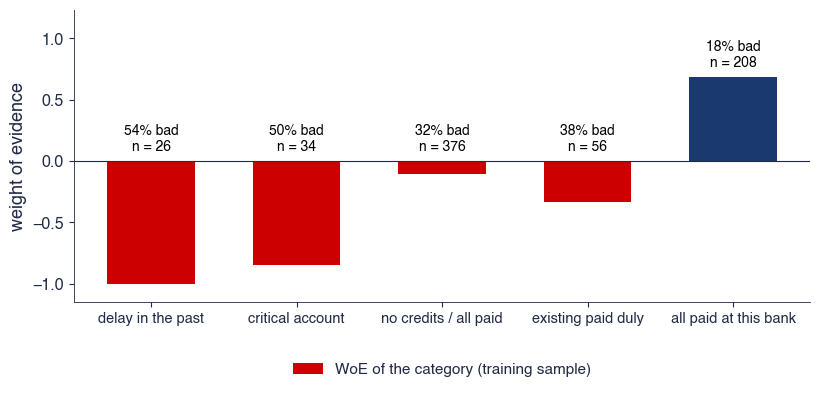

In [15]:
# Solution
def b1_scorecard(save=True):
    """South German Credit: IV on the training sample, WoE logit on the variables with IV >= 0.10, test AUC with a
    DeLong interval; chart: WoE of the credit-history categories."""
    S = sgc_scorecard()
    y = S['y'][S['te']]
    d = delong(S['p_te'], y)
    t = S['tables']['credit_history']
    labs = {0: 'delay in the past', 1: 'critical account', 2: 'no credits / all paid', 3: 'existing paid duly',
            4: 'all paid at this bank'}
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    x = np.arange(len(t))
    ax.bar(x, t['woe'], color=[st.MainBlue if w > 0 else st.IDAred for w in t['woe']], width=0.6,
           label='WoE of the category (training sample)')
    ax.axhline(0, color=st.DarkText, lw=0.8)
    for xi, (w, n, r) in zip(x, t[['woe', 'n', 'bad_rate']].values):
        ax.text(xi, max(w, 0) + 0.06, f'{100 * r:.0f}% bad\nn = {int(n)}', ha='center', va='bottom', fontsize=10,
                color='black')
    ax.set_ylim(min(t['woe']) - 0.15, max(t['woe']) + 0.55)
    ax.set_xticks(x)
    ax.set_xticklabels([labs[i] for i in t.index], fontsize=10.5)
    ax.set_ylabel('weight of evidence')
    st.legend_outside_bottom(ax, ncol=1, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch12_sem_b1')
    return {'iv': {k: float(v) for k, v in S['iv'].items()}, 'sel': S['sel'], 'b': S['logit']['b'].tolist(),
            'se': S['logit']['se'].tolist(), 'auc_train': auc(S['p_tr'], S['y'][S['tr']]), 'auc': d['auc'],
            'lo': d['lo'], 'hi': d['hi'], 'se_auc': d['se'], 'n_train': int(len(S['tr'])), 'n_test': int(len(S['te'])),
            'woe_ch': t['woe'].round(4).tolist(), 'rate_ch': t['bad_rate'].round(4).tolist()}


b1 = b1_scorecard(save=False)
print({k: b1[k] for k in ['sel', 'auc_train', 'auc', 'lo', 'hi']})
pd.DataFrame({'b': b1['b'], 'se': b1['se']}, index=['const'] + b1['sel']).round(3)

**Interpretation of the result.** Yes: a delay in the past and a critical account are the riskiest groups, all credits at this bank paid back duly the safest. Test AUC 0.801, 95% interval [0.749, 0.854].

## B2 [Proposed]: information value of the Taiwan data

**Question.** Which kind of information predicts the default of a card holder: payment behaviour or personal data? Model: B1.

1. Compute the IV of PAY_0, PAY_2, LIMIT_BAL, PAY_AMT1, BILL_AMT1, AGE, SEX, EDUCATION and MARRIAGE on the training sample.
2. Compute the default rate of each PAY_0 category.
3. Rank the variables by IV and classify them with the rule of thumb.
4. Interpretation: why is the last month's repayment status so much stronger than the personal data?

**Report:** a table of nine IVs, six default rates and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: validating the scorecard

**Question.** How good is the B1 scorecard on the test sample, and which cut-off should the bank use?

1. Build the confusion matrix at the cut-offs 0.5 and 1/6, with accuracy, TPR, FPR and the cost per applicant.
2. Compute the AUC, the Gini, the accuracy ratio of the CAP curve and the KS statistic.
3. Compute the Brier score, compare it with a constant PD of 30%, and run the Hosmer–Lemeshow test with five groups.
4. Draw the ROC curve with the two cut-offs and the calibration plot.
5. Interpretation: which cut-off would you recommend to the bank?

**Report:** two confusion matrices, six statistics, the chart and two sentences.

{'cut': 0.5, 'TP': 43, 'FN': 47, 'FP': 25, 'TN': 185, 'acc': 0.76, 'tpr': 0.4777777777777778, 'tnr': 0.8809523809523809, 'fpr': 0.11904761904761904, 'precision': 0.6323529411764706, 'cost': 0.8666666666666667, 'reject': 0.22666666666666666}
{'cut': 0.16666666666666666, 'TP': 82, 'FN': 8, 'FP': 112, 'TN': 98, 'acc': 0.6, 'tpr': 0.9111111111111111, 'tnr': 0.4666666666666667, 'fpr': 0.5333333333333333, 'precision': 0.422680412371134, 'cost': 0.5066666666666667, 'reject': 0.6466666666666666}


{'auc': 0.8013227513227513,
 'gini': 0.6026455026455027,
 'ar': 0.6020105820105821,
 'ks': 0.5111111111111111,
 'brier': 0.16217283209875974,
 'brier_ref': 0.21,
 'hl': 0.5887901237353541,
 'hl_p': 0.8989937549095697}

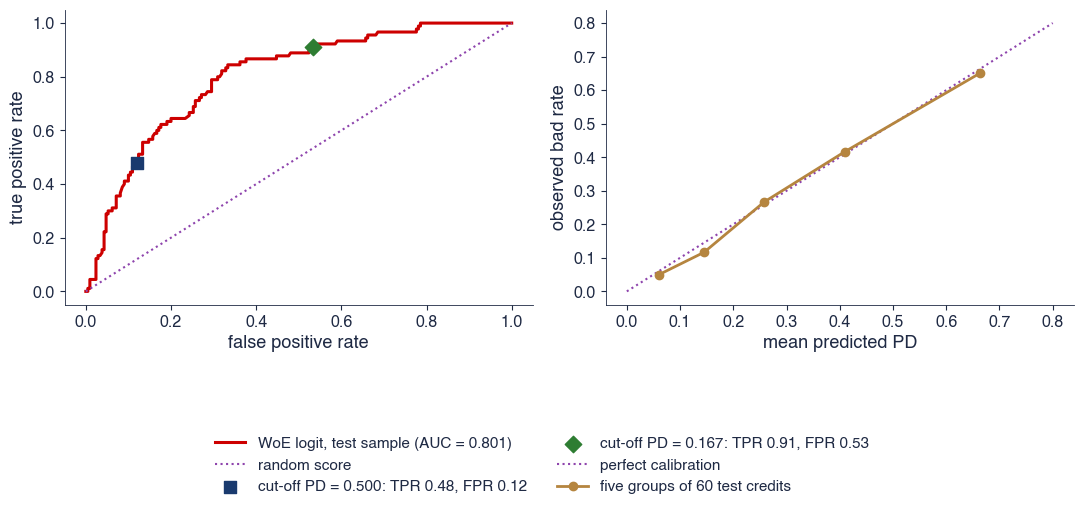

In [17]:
# Solution
def b3_validation(save=True):
    """Validation of the South German Credit scorecard on the test sample; chart: ROC and calibration."""
    S = sgc_scorecard()
    y, p = S['y'][S['te']], S['p_te']
    t, hl, php = calibration_table(p, y, 5)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    f, tp, _ = roc_points(p, y)
    axes[0].plot(f, tp, color=st.IDAred, lw=2.2, label=f'WoE logit, test sample (AUC = {auc(p, y):.3f})')
    axes[0].plot([0, 1], [0, 1], color=st.Purple, ls=':', lw=1.5, label='random score')
    for c, col, mk in [(0.5, st.MainBlue, 's'), (COST_FP / (COST_FP + COST_FN), st.Forest, 'D')]:
        cm = confusion(p, y, c)
        axes[0].scatter([cm['fpr']], [cm['tpr']], color=col, marker=mk, s=70, zorder=3,
                        label=f'cut-off PD = {c:.3f}: TPR {cm["tpr"]:.2f}, FPR {cm["fpr"]:.2f}')
    axes[0].set_xlabel('false positive rate')
    axes[0].set_ylabel('true positive rate')
    axes[1].plot([0, 0.8], [0, 0.8], color=st.Purple, ls=':', lw=1.5, label='perfect calibration')
    axes[1].plot(t['pd_mean'], t['rate'], 'o-', color=st.Amber, lw=2, label='five groups of 60 test credits')
    axes[1].set_xlabel('mean predicted PD')
    axes[1].set_ylabel('observed bad rate')
    st.fig_legend_bottom(fig, ncol=2, y=0.02)
    fig.tight_layout(rect=(0, 0.14, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch12_sem_b3')
    return {'cm50': confusion(p, y, 0.5), 'cm_cost': confusion(p, y, COST_FP / (COST_FP + COST_FN)), 'auc': auc(p, y),
            'gini': 2 * auc(p, y) - 1, 'ar': accuracy_ratio(p, y), 'ks': ks_stat(p, y)['ks'], 'brier': brier(p, y),
            'brier_ref': brier(np.full(len(y), S['y'][S['tr']].mean()), y), 'hl': hl, 'hl_p': php,
            'cal': t.round(4).to_dict('index'), 'all_good_acc': float(np.mean(y == 0))}


b3 = b3_validation(save=False)
print(b3['cm50'])
print(b3['cm_cost'])
{k: b3[k] for k in ['auc', 'gini', 'ar', 'ks', 'brier', 'brier_ref', 'hl', 'hl_p']}

**Interpretation of the result.** The cut-off of 1/6: it rejects more applicants but catches 91% of the bads, and the cost per applicant falls from 0.867 to 0.507.

## B4 [Proposed]: logit or LDA on the Taiwan data?

**Question.** Do the logit and Fisher's LDA differ in ranking or in calibration? Model: B3.

1. Estimate a logit and an LDA on the training sample with the same inputs.
2. Compute the test AUC of both and the DeLong test of equal AUCs.
3. Compute the Brier score, the Hosmer–Lemeshow statistic (ten groups) and the mean PD of both, against the default rate.
4. Compute the accuracy of the rule "nobody defaults" and of both models at the cut-off 0.5.
5. Interpretation: is the LDA worse at ranking or at calibration?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B5 [Solved]: from PDs to capital

**Question.** How much expected loss and Basel capital does the test portfolio of B1 carry, and how much does the prior correction matter?

1. Correct the PD of every credit from the sample rate of 30% to the population rate of 5%.
2. Compute the expected loss of the portfolio, in DM and as a share of EAD, with and without the correction.
3. Compute the IRB capital K and the risk-weighted assets of the portfolio with the corrected PDs.
4. Interpretation: why does the correction change the expected loss but not the AUC?

**Report:** eight numbers and two sentences.

In [19]:
# Solution
def b5_capital(lgd=0.45):
    """Test portfolio of the South German Credit scorecard: PDs corrected from the 30% sample to a 5% population,
    EAD = credit amount, LGD = 45%: expected loss, IRB capital (other retail) and risk-weighted assets."""
    S = sgc_scorecard()
    df = load_credit('sgc')
    p = S['p_te']
    shift = prior_shift(0.3, POP_BAD)
    pc = 1 / (1 + np.exp(-(np.log(p / (1 - p)) + shift)))
    ead = df['amount'].values[S['te']].astype(float)
    K, R = irb_capital(pc, lgd)
    el = pc * lgd * ead
    return {'shift': shift, 'mean_pd_sample': float(p.mean()), 'mean_pd_pop': float(pc.mean()),
            'ead': float(ead.sum()), 'el': float(el.sum()), 'el_pct': float(el.sum() / ead.sum()),
            'k': float((K * ead).sum()), 'k_pct': float((K * ead).sum() / ead.sum()),
            'rwa': float(12.5 * (K * ead).sum()), 'rwa_density': float(12.5 * (K * ead).sum() / ead.sum()),
            'median_pd_pop': float(np.median(pc)), 'max_pd_pop': float(pc.max()), 'n': int(len(p)),
            'el_naive_pct': float((p * lgd * ead).sum() / ead.sum())}


b5_capital()

{'shift': -2.097141118779237,
 'mean_pd_sample': 0.30724517261859924,
 'mean_pd_pop': 0.07267961969152548,
 'ead': 957819.0,
 'el': 41743.68997168523,
 'el_pct': 0.043582023296348506,
 'k': 54541.712040573126,
 'k_pct': 0.05694365223551958,
 'rwa': 681771.4005071641,
 'rwa_density': 0.7117956529439947,
 'median_pd_pop': 0.042052368672150925,
 'max_pd_pop': 0.5435562506703783,
 'n': 300,
 'el_naive_pct': 0.16290614217310137}

**Interpretation of the result.** The correction adds the same constant to every log-odds: the ranking, hence the AUC, is unchanged, while every PD shrinks and the expected loss falls from 16.3% to 4.4% of EAD.

## B6 [Proposed]: fairness on the Taiwan data

**Question.** Does the logit of B4 treat men and women, and young and older clients, alike? Model: B5.

1. Compute the approval rate and the default rate of men and women, and of clients up to 25 years and older.
2. Compute the approval rate of the good payers (equal opportunity) in each group.
3. Compute the default rate among the approved clients of each group.
4. Interpretation: which fairness criterion does the model come closest to satisfying?

**Report:** one table and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: does gradient boosting beat the logit?

**Question.** Benchmarks report gains for flexible models (Lessmann et al., 2015); how large is the gain on the Taiwan data, and is it worth the loss of a simple scorecard? Models: B3, B4.

1. Fit gradient boosting (scikit-learn, default settings) on the training sample.
2. Compare its test AUC with the logit by the DeLong test, and compare the Brier scores.
3. Compare the training and the test AUC of gradient boosting.
4. Interpretation: is the gain large enough to replace the scorecard?

**Report:** a table and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant summarised the B1 scorecard. It answered:

- (a) the AUC is 0.80, so the scorecard classifies 80% of the applicants correctly;
- (b) the Gini coefficient is AUC − 0.5 = 0.30;
- (c) an applicant with a PD of 30% from this model has a 30% chance of default at the bank;
- (d) with PDO = 20, a PD that halves from 20% to 10% adds exactly 20 points;
- (e) KS is the largest vertical gap between the score distributions of bads and goods;
- (f) LDA may only be used when every variable is Normally distributed.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
